In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
# import matplotlib
# matplotlib.use("Agg")
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

In [2]:
params = {'legend.fontsize': 'large',
         'axes.labelsize': 'large',
         'axes.titlesize':'large',
         'xtick.labelsize':'large',
         'ytick.labelsize':'large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
cat = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_data/everest/sv1_perexp_lrg.fits'))
cat['EFFTIME_ELG'] = 8.60 * cat['TSNR2_ELG']
cat['EFFTIME_LRG'] = 12.15 * cat['TSNR2_LRG']

# Remove FIBERSTATUS!=0 fibers
mask = cat['FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove "no data" fibers
mask = cat['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Apply LRG mask
mask = cat['lrg_mask']==0
print('LRG mask', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove QSO targets
mask = cat['SV1_DESI_TARGET'] & 2**2 ==0
print('Remove QSO targets', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# mask = cat['EFFTIME_DARK_GFA']!=0
# print('EFFTIME_GFA', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
# cat = cat[mask]

# # Require a minimum depth
# min_depth = 500.
# mask = cat['EFFTIME_LRG']>min_depth
# print('Min depth', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
# cat = cat[mask]

# Julien's bad fibers list
bad_fibers = np.array(Table.read('/Users/rongpu/Documents/Data/desi_data/everest/misc/badfibers.csv')['FIBER'])
bad_fibers = np.append(bad_fibers, np.arange(2663, 2674+1))  # fibers affected by the CCD z5 defect
bad_fibers = np.append(bad_fibers, [3402, 3429])  # "swapped" fibers
bad_fibers = np.unique(bad_fibers)
print(len(bad_fibers))
mask_bad = np.in1d(cat['FIBER'], bad_fibers)
print('Bad fibers', np.sum(~mask_bad), np.sum(mask_bad), np.sum(mask_bad)/len(mask_bad))
cat = cat[~mask_bad]
print(len(cat))

FIBERSTATUS 414186 91655 0.18119329987090804
No data 414186 0 0.0
LRG mask 371619 42567 0.10277266735234894
Remove QSO targets 360700 10919 0.029382243642009694
199
Bad fibers 346572 14128 0.039168283892431384
346572


In [4]:
cat_1x = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_data/everest/sv1_1x_depth_lrg.fits'))
cat_1x['EFFTIME_ELG'] = 8.60 * cat_1x['TSNR2_ELG']
cat_1x['EFFTIME_LRG'] = 12.15 * cat_1x['TSNR2_LRG']

# Remove FIBERSTATUS!=0 fibers
mask = cat_1x['COADD_FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat_1x = cat_1x[mask]

# Remove "no data" fibers
mask = cat_1x['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat_1x = cat_1x[mask]

# Apply LRG mask
mask = cat_1x['lrg_mask']==0
print('LRG mask', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat_1x = cat_1x[mask]

# Remove QSO targets
mask = cat_1x['SV1_DESI_TARGET'] & 2**2 ==0
print('Remove QSO targets', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat_1x = cat_1x[mask]

# mask = cat_1x['EFFTIME_DARK_GFA']!=0
# print('EFFTIME_GFA', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
# cat_1x = cat_1x[mask]

# # Require a minimum depth
# min_depth = 500.
# mask = cat_1x['EFFTIME_LRG']>min_depth
# print('Min depth', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
# cat_1x = cat_1x[mask]

# Julien's bad fibers list
bad_fibers = np.array(Table.read('/Users/rongpu/Documents/Data/desi_data/everest/misc/badfibers.csv')['FIBER'])
bad_fibers = np.append(bad_fibers, np.arange(2663, 2674+1))  # fibers affected by the CCD z5 defect
bad_fibers = np.append(bad_fibers, [3402, 3429])  # "swapped" fibers
bad_fibers = np.unique(bad_fibers)
print(len(bad_fibers))
mask_bad = np.in1d(cat_1x['FIBER'], bad_fibers)
print('Bad fibers', np.sum(~mask_bad), np.sum(mask_bad), np.sum(mask_bad)/len(mask_bad))
cat_1x = cat_1x[~mask_bad]
print(len(cat_1x))

FIBERSTATUS 27179 4874 0.15206064954918416
No data 27179 0 0.0
LRG mask 25072 2107 0.07752308767798669
Remove QSO targets 24557 515 0.020540842373962986
199
Bad fibers 23663 894 0.03640509834263143
23663


In [5]:
columns = list(np.intersect1d(cat.colnames, cat_1x.colnames))
cat = cat[columns]
cat_1x = cat_1x[columns]

cat = vstack([cat, cat_1x])

In [6]:
deep = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_data/everest/sv1_cumulative_lrg.fits'))
deep['EFFTIME_ELG'] = 8.60 * deep['TSNR2_ELG']
deep['EFFTIME_LRG'] = 12.15 * deep['TSNR2_LRG']

# Remove FIBERSTATUS!=0 fibers
mask = deep['COADD_FIBERSTATUS']==0
print('COADD_FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

mask = deep['ZWARN']==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

# Apply LRG mask
mask = deep['lrg_mask']==0
print('LRG mask', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

# Remove QSO targets
mask = deep['SV1_DESI_TARGET'] & 2**2 ==0
print('Remove QSO targets', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

# Require a minimum depth
min_depth = 3000.
mask = deep['EFFTIME_LRG']>min_depth
print('Min depth', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
deep = deep[mask]

# Julien's bad fibers list
bad_fibers = np.array(Table.read('/Users/rongpu/Documents/Data/desi_data/everest/misc/badfibers.csv')['FIBER'])
bad_fibers = np.append(bad_fibers, np.arange(2663, 2674+1))  # fibers affected by the CCD z5 defect
bad_fibers = np.append(bad_fibers, [3402, 3429])  # "swapped" fibers
bad_fibers = np.unique(bad_fibers)
print(len(bad_fibers))
mask_bad = np.in1d(deep['FIBER'], bad_fibers)
print('Bad fibers', np.sum(~mask_bad), np.sum(mask_bad), np.sum(mask_bad)/len(mask_bad))
deep = deep[~mask_bad]
print(len(deep), len(np.unique(deep['TARGETID'])))

# Remove duplidates keeping the higher EFFTIME objects
deep.sort('EFFTIME_LRG', reverse=True)
_, idx_keep = np.unique(deep['TARGETID'], return_index=True)
deep = deep[idx_keep]
print(len(deep), len(np.unique(deep['TARGETID'])))

deep_columns_old = ['TARGETID', 'Z', 'ZERR', 'ZWARN', 'SPECTYPE', 'DELTACHI2', 'EFFTIME_LRG', 'EFFTIME_ELG']
deep_columns_new = ['TARGETID', 'Z_deep', 'ZERR_deep', 'ZWARN_deep', 'SPECTYPE_deep', 'DELTACHI2_deep', 'EFFTIME_LRG_deep', 'EFFTIME_ELG_deep']
deep.rename_columns(deep_columns_old, deep_columns_new)

cat = join(cat, deep[deep_columns_new], keys='TARGETID')

COADD_FIBERSTATUS 46403 8832 0.15989861500859961
No data 45392 1011 0.021787384436351098
LRG mask 41301 4091 0.09012601339443074
Remove QSO targets 39607 1694 0.041015956030120336
Min depth 30657 8950 0.7740298432095337
199
Bad fibers 29459 1198 0.03907753531004338
29459 29417
29417 29417


In [7]:
main = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_data/everest/main_cumulative_lrg.fits'))
main['EFFTIME_ELG'] = 8.60 * main['TSNR2_ELG']
main['EFFTIME_LRG'] = 12.15 * main['TSNR2_LRG']

# Remove FIBERSTATUS!=0 fibers
mask = main['COADD_FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
main = main[mask]

# Remove "no data" fibers
mask = main['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
main = main[mask]

# Apply LRG mask
mask = main['lrg_mask']==0
print('LRG mask', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
main = main[mask]

# Remove QSO targets
mask = main['DESI_TARGET'] & 2**2 ==0
print('Remove QSO targets', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
main = main[mask]

# mask = main['EFFTIME_DARK_GFA']!=0
# print('EFFTIME_GFA', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
# main = main[mask]

# # Require a minimum depth
# min_depth = 500.
# mask = main['EFFTIME_LRG']>min_depth
# print('Min depth', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
# main = main[mask]

# Julien's bad fibers list
bad_fibers = np.array(Table.read('/Users/rongpu/Documents/Data/desi_data/everest/misc/badfibers.csv')['FIBER'])
bad_fibers = np.append(bad_fibers, np.arange(2663, 2674+1))  # fibers affected by the CCD z5 defect
bad_fibers = np.append(bad_fibers, [3402, 3429])  # "swapped" fibers
bad_fibers = np.unique(bad_fibers)
print(len(bad_fibers))
mask_bad = np.in1d(main['FIBER'], bad_fibers)
print('Bad fibers', np.sum(~mask_bad), np.sum(mask_bad), np.sum(mask_bad)/len(mask_bad))
main = main[~mask_bad]
print(len(main))

FIBERSTATUS 340944 5119 0.014792104327824702
No data 340944 0 0.0
LRG mask 306665 34279 0.10054143789009339
Remove QSO targets 301954 4711 0.015362040011087017
199
Bad fibers 290370 11584 0.038363459334865575
290370


---------

In [8]:
# Catastrophic redshift failures
zdiff_threshold = 0.0033
mask_fail = np.abs((cat['Z'] - cat['Z_deep'])/(1 + cat['Z_deep'])) > zdiff_threshold
print(np.sum(mask_fail), np.sum(mask_fail)/len(mask_fail))
# Also reject objects with ZWARN!=0 or z>1.4 or DELTACHI2<15 in the deep coadds
mask_deep = (cat['ZWARN_deep']==0) & (cat['Z_deep']<1.4)
mask_deep_fail = ~mask_deep
# mask_deep = (cat['ZWARN_deep']==0) & (cat['Z_deep']<1.4) & (cat['DELTACHI2_deep']>30)
mask_fail |= mask_deep_fail
print(np.sum(mask_fail), np.sum(mask_fail)/len(mask_fail))
print()

mask = cat['main_lrg'].copy()
print(np.sum(mask_fail & mask), np.sum(mask_fail & mask)/np.sum(mask))
mask &= cat['EFFTIME_LRG']>800
print(np.sum(mask_fail & mask), np.sum(mask_fail & mask)/np.sum(mask))

75596 0.23034147798080995
76196 0.23216968167926605

12411 0.13688552615615385
222 0.013471691243400691


In [9]:
# mask_quality = cat['ZWARN']==0
# mask_quality &= cat['Z']<1.4
# mask_quality &= cat['DELTACHI2']>15

# Custom DELTACHI2 vs z cut
d = (10**(3 - 3.5*cat['Z']))
mask_remove = (d>30) & (cat['DELTACHI2']<30)
mask_remove |= (d<30) & (cat['DELTACHI2']<d)
mask_remove |= (cat['DELTACHI2']<10)
mask_quality = cat['ZWARN']==0
mask_quality &= cat['Z']<1.4
mask_quality &= (~mask_remove)

print(np.sum((~mask_quality)), np.sum((~mask_quality))/len((~mask_quality)))
mask = cat['EFFTIME_LRG']>800
# Failures in "good redshifts"
print(np.sum(mask_fail & mask_quality & mask), np.sum(mask_fail & mask_quality & mask)/np.sum(mask_quality & mask))
print()

mask = cat['main_lrg'].copy()
print(np.sum((~mask_quality) & mask), np.sum((~mask_quality) & mask)/np.sum(mask))
mask &= cat['EFFTIME_LRG']>800
# Failures in "good redshifts"
print(np.sum(mask_fail & mask_quality & mask), np.sum(mask_fail & mask_quality & mask)/np.sum(mask_quality & mask))

97616 0.2974365537141482
425 0.007734444666872919

16179 0.17844419689633495
56 0.0034495503264752986


In [10]:
# mask_quality_main = main['ZWARN']==0
# mask_quality_main &= main['Z']<1.4
# mask_quality_main &= main['DELTACHI2']>15

# Custom DELTACHI2 vs z cut
d = (10**(3 - 3.5*main['Z']))
mask_remove = (d>30) & (main['DELTACHI2']<30)
mask_remove |= (d<30) & (main['DELTACHI2']<d)
mask_remove |= (main['DELTACHI2']<10)
mask_quality_main = main['ZWARN']==0
mask_quality_main &= main['Z']<1.4
mask_quality_main &= (~mask_remove)

print(np.sum((~mask_quality_main)), np.sum((~mask_quality_main))/len((~mask_quality_main)))
mask = main['EFFTIME_LRG']>800
print(np.sum((~mask_quality_main) & mask), np.sum((~mask_quality_main) & mask)/np.sum(mask))
print()

6099 0.021004235974790786
5665 0.0199808832502707



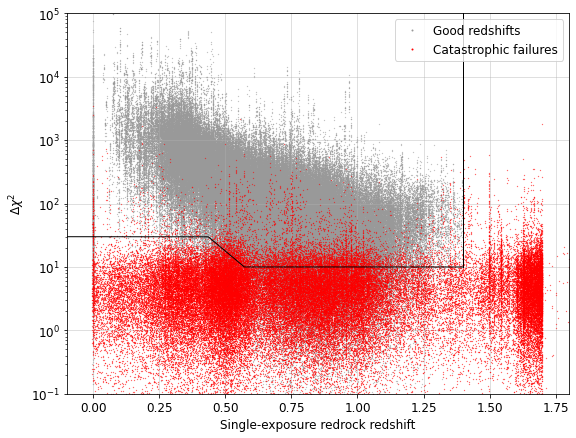

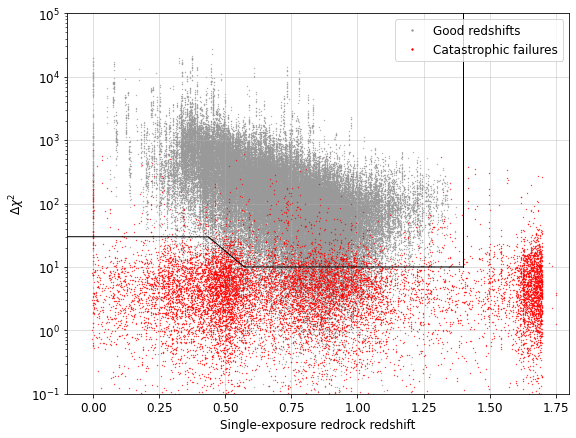

In [11]:
x = np.linspace(-1, 1.4, 10000)
y = np.ones_like(x)
y = (10**(3 - 3.5*x))
y[y<10] = 10
y[y>30] = 30

y1 = np.linspace(10, 1e6)
x1 = np.ones_like(y1) * 1.4

mask = np.full(len(cat), True)
plt.figure(figsize=(9, 7))
plt.plot(cat['Z'][mask & (~mask_fail)], cat['DELTACHI2'][mask & (~mask_fail)], '.', color='0.6', ms=0.5, alpha=1, label='Good redshifts', zorder=1)
plt.plot(cat['Z'][mask & mask_fail], cat['DELTACHI2'][mask & mask_fail], 'r.', ms=0.5, alpha=1, label='Catastrophic failures', zorder=2)
plt.plot(x, y, color='k', lw=1)
plt.plot(x1, y1, color='k', lw=1)
# plt.axhline(9., ls='--', color='0.6', label='ZWARN threshold')
plt.yscale('log')
plt.xlabel('Single-exposure redrock redshift')
plt.ylabel('$\Delta \chi^2$')
plt.axis([-0.1, 1.8, .1, 100000])
plt.legend(markerscale=4, loc='upper right')
plt.grid(alpha=0.5)
plt.show()

mask = cat['main_lrg'].copy()
plt.figure(figsize=(9, 7))
plt.plot(cat['Z'][mask & (~mask_fail)], cat['DELTACHI2'][mask & (~mask_fail)], '.', color='0.6', ms=0.7, alpha=1, label='Good redshifts', zorder=1)
plt.plot(cat['Z'][mask & mask_fail], cat['DELTACHI2'][mask & mask_fail], 'r.', ms=0.7, alpha=1, label='Catastrophic failures', zorder=2)
plt.plot(x, y, color='k', lw=1)
plt.plot(x1, y1, color='k', lw=1)
# plt.axhline(9., ls='--', color='0.6', label='ZWARN threshold')
plt.yscale('log')
plt.xlabel('Single-exposure redrock redshift')
plt.ylabel('$\Delta \chi^2$')
plt.axis([-0.1, 1.8, .1, 100000])
plt.legend(markerscale=4, loc='upper right')
plt.grid(alpha=0.5)
plt.show()

In [13]:
cat['zfibermag'] = 22.5 - 2.5*np.log10(cat['FIBERFLUX_Z']) - 1.211 * cat['EBV']
main['zfibermag'] = 22.5 - 2.5*np.log10(main['FIBERFLUX_Z']) - 1.211 * main['EBV']

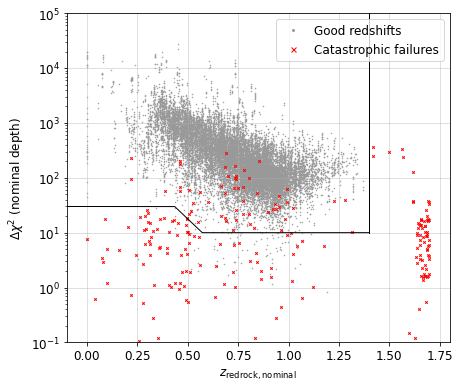

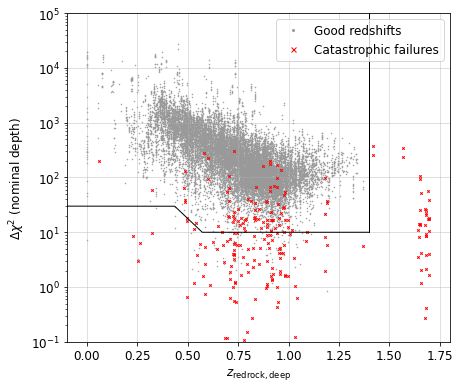

In [63]:
mask = cat['main_lrg'].copy()
mask &= cat['EFFTIME_LRG']>800
plt.figure(figsize=(6.5, 5.5))
plt.plot(cat['Z'][mask & (~mask_fail)], cat['DELTACHI2'][mask & (~mask_fail)], '.', color='0.6', ms=1, alpha=1, zorder=1, rasterized=True)
plt.plot(cat['Z'][mask & mask_fail], cat['DELTACHI2'][mask & mask_fail], 'rx', ms=2.5, alpha=1, zorder=2, rasterized=True)
plt.plot(-1, 0, '.', color='0.6', ms=4, alpha=1, label='Good redshifts', zorder=1, rasterized=True)
plt.plot(-1, 0, 'rx', ms=5, alpha=1, label='Catastrophic failures', zorder=2, rasterized=True)
plt.plot(x, y, color='k', lw=1)
plt.plot(x1, y1, color='k', lw=1)
# plt.axhline(9., ls='--', color='0.6', label='ZWARN threshold')
plt.yscale('log')
plt.xlabel('$z_\mathrm{redrock,nominal}$')
plt.ylabel('$\Delta \chi^2$ (nominal depth)')
plt.axis([-0.1, 1.8, .1, 100000])
plt.legend(markerscale=1, loc='upper right')
plt.grid(alpha=0.5)
plt.tight_layout()
plt.savefig('/Users/rongpu/git/desi-targets/lrg_paper/figures/main_dchi2_vs_z.pdf', dpi=150)
plt.show()

plt.figure(figsize=(6.5, 5.5))
plt.plot(cat['Z_deep'][mask & (~mask_fail)], cat['DELTACHI2'][mask & (~mask_fail)], '.', color='0.6', ms=1, alpha=1, zorder=1, rasterized=True)
plt.plot(cat['Z_deep'][mask & mask_fail], cat['DELTACHI2'][mask & mask_fail], 'rx', ms=2.5, alpha=1, zorder=2, rasterized=True)
plt.plot(-1, 0, '.', color='0.6', ms=4, alpha=1, label='Good redshifts', zorder=1, rasterized=True)
plt.plot(-1, 0, 'rx', ms=5, alpha=1, label='Catastrophic failures', zorder=2, rasterized=True)
plt.plot(x, y, color='k', lw=1)
plt.plot(x1, y1, color='k', lw=1)
# plt.axhline(9., ls='--', color='0.6', label='ZWARN threshold')
plt.yscale('log')
plt.xlabel('$z_\mathrm{redrock,deep}$')
plt.ylabel('$\Delta \chi^2$ (nominal depth)')
plt.axis([-0.1, 1.8, .1, 100000])
plt.legend(markerscale=1, loc='upper right')
plt.grid(alpha=0.5)
plt.tight_layout()
plt.savefig('/Users/rongpu/git/desi-targets/lrg_paper/figures/main_dchi2_vs_z_deep.pdf', dpi=150)
plt.show()

In [62]:
# mask = (cat['EFFTIME_LRG']>800) & (cat['zfibermag']<21.8)
# mask1 = mask & (cat['main_lrg'])
# mask2 = mask & (~cat['main_lrg'])
# plt.figure(figsize=(6.5, 5.5))
# plt.plot(cat['Z'][mask & (~mask_fail)], cat['DELTACHI2'][mask & (~mask_fail)], '.', color='0.6', ms=1, alpha=1, label='Good redshifts', zorder=1, rasterized=True)
# plt.plot(cat['Z'][mask1 & mask_fail], cat['DELTACHI2'][mask1 & mask_fail], 'rx', ms=3., alpha=1, label='Catastrophic failures', zorder=3, rasterized=True)
# plt.plot(cat['Z'][mask2 & mask_fail], cat['DELTACHI2'][mask2 & mask_fail], '.', color='darkorange', ms=1., alpha=1, label='Catastrophic failures', zorder=2, rasterized=True)
# plt.plot(x, y, color='k', lw=1)
# plt.plot(x1, y1, color='k', lw=1)
# # plt.axhline(9., ls='--', color='0.6', label='ZWARN threshold')
# plt.yscale('log')
# plt.xlabel('Single-exposure redrock redshift')
# plt.ylabel('$\Delta \chi^2$')
# plt.axis([-0.1, 1.8, .1, 100000])
# plt.legend(markerscale=4, loc='upper right')
# plt.grid(alpha=0.5)
# plt.tight_layout()
# plt.savefig('/Users/rongpu/git/desi-targets/lrg_paper/figures/main_dchi2_vs_z-1.pdf', dpi=200)
# plt.show()

# plt.figure(figsize=(6.5, 5.5))
# plt.plot(cat['Z_deep'][mask & (~mask_fail)], cat['DELTACHI2'][mask & (~mask_fail)], '.', color='0.6', ms=1, alpha=1, label='Good redshifts', zorder=1, rasterized=True)
# plt.plot(cat['Z_deep'][mask1 & mask_fail], cat['DELTACHI2'][mask1 & mask_fail], 'rx', ms=3., alpha=1, label='Catastrophic failures', zorder=3, rasterized=True)
# plt.plot(cat['Z_deep'][mask2 & mask_fail], cat['DELTACHI2'][mask2 & mask_fail], '.', color='darkorange', ms=1., alpha=1, label='Catastrophic failures', zorder=2, rasterized=True)
# plt.plot(x, y, color='k', lw=1)
# plt.plot(x1, y1, color='k', lw=1)
# # plt.axhline(9., ls='--', color='0.6', label='ZWARN threshold')
# plt.yscale('log')
# plt.xlabel('Deep redrock redshift')
# plt.ylabel('$\Delta \chi^2$')
# plt.axis([-0.1, 1.8, .1, 100000])
# plt.legend(markerscale=1, loc='upper right')
# plt.grid(alpha=0.5)
# plt.tight_layout()
# plt.savefig('/Users/rongpu/git/desi-targets/lrg_paper/figures/main_dchi2_vs_z_deep-1.pdf', dpi=150)
# plt.show()

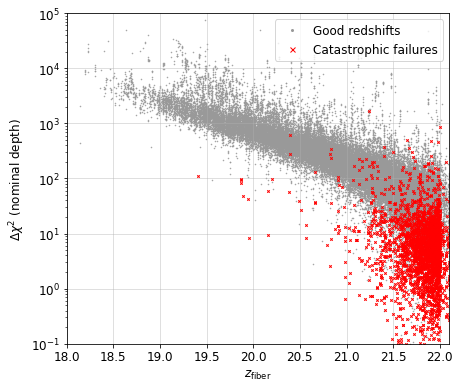

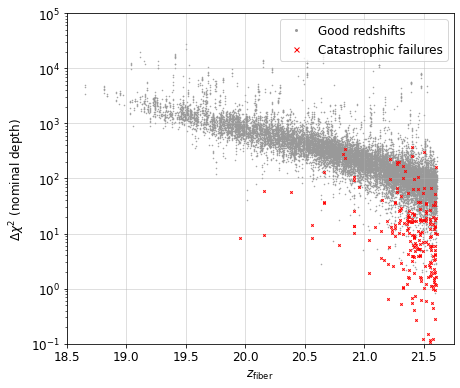

In [61]:
mask = cat['EFFTIME_LRG']>800
plt.figure(figsize=(6.5, 5.5))
plt.plot(cat['zfibermag'][mask & (~mask_fail)], cat['DELTACHI2'][mask & (~mask_fail)], '.', color='0.6', ms=1, alpha=1, zorder=1, rasterized=True)
plt.plot(cat['zfibermag'][mask & mask_fail], cat['DELTACHI2'][mask & mask_fail], 'rx', ms=2.5, alpha=1, zorder=2, rasterized=True)
plt.plot(-1, 0, '.', color='0.6', ms=4, alpha=1, label='Good redshifts', zorder=1, rasterized=True)
plt.plot(-1, 0, 'rx', ms=5, alpha=1, label='Catastrophic failures', zorder=2, rasterized=True)
plt.yscale('log')
plt.xlabel('$z_\mathrm{fiber}$')
plt.ylabel('$\Delta \chi^2$ (nominal depth)')
plt.axis([18., 22.1, .1, 100000])
plt.axvline(1.4, color='k')
plt.legend(markerscale=1, loc='upper right')
plt.grid(alpha=0.5)
plt.tight_layout()
plt.show()

mask = cat['main_lrg'].copy()
mask &= cat['EFFTIME_LRG']>800
plt.figure(figsize=(6.5, 5.5))
plt.plot(cat['zfibermag'][mask & (~mask_fail)], cat['DELTACHI2'][mask & (~mask_fail)], '.', color='0.6', ms=1, alpha=1, zorder=1, rasterized=True)
plt.plot(cat['zfibermag'][mask & mask_fail], cat['DELTACHI2'][mask & mask_fail], 'rx', ms=2.5, alpha=1, zorder=2, rasterized=True)
plt.plot(-1, 0, '.', color='0.6', ms=4, alpha=1, label='Good redshifts', zorder=1, rasterized=True)
plt.plot(-1, 0, 'rx', ms=5, alpha=1, label='Catastrophic failures', zorder=2, rasterized=True)
plt.yscale('log')
plt.xlabel('$z_\mathrm{fiber}$')
plt.ylabel('$\Delta \chi^2$ (nominal depth)')
plt.axis([18.5, 21.75, .1, 100000])
plt.axvline(1.4, color='k')
plt.legend(markerscale=1, loc='upper right')
plt.grid(alpha=0.5)
plt.tight_layout()
plt.savefig('/Users/rongpu/git/desi-targets/lrg_paper/figures/main_dchi2_vs_zfiber.pdf', dpi=150)
plt.show()

In [15]:
def binned_frac(x, y, bin_edges, minsize=10, error_floor=True):
    bin_center = (bin_edges[1:] + bin_edges[:-1])/2
    bin_frac = np.zeros(len(bin_edges)-1)
    bin_frac_err = np.zeros(len(bin_edges)-1)
    for index in range(len(bin_edges)-1):
        mask = (x>bin_edges[index]) & (x<=bin_edges[index+1])
        if np.sum(mask)<minsize:
            bin_frac[index] = np.nan
            bin_frac_err[index] = np.nan
        else:
            n, p = np.sum(mask), np.mean(y[mask])
            if error_floor:
                p1 = np.maximum(p, 1/n)  # error floor
            else:
                p1 = p
            bin_frac[index] = p
            bin_frac_err[index] = np.clip(np.sqrt(n * p * (1-p))/n, np.sqrt(n * p1 * (1-p1))/n, 1)
    
    return bin_center, bin_frac, bin_frac_err

------------
# Failures rates vs EFFTIME

__SV1 LRGs__

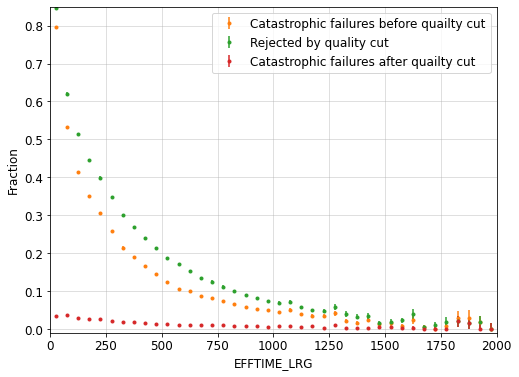

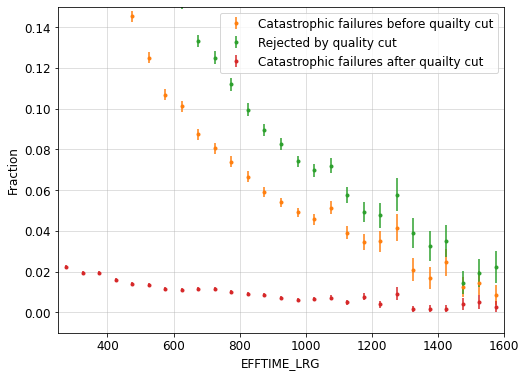

In [16]:
mask = np.full(len(cat), True)
bin_edges = np.linspace(0, 2000, 41)
bin_center, bin_reject_rate, bin_reject_rate_err = binned_frac(cat['EFFTIME_LRG'][mask], (~mask_quality)[mask], bin_edges, minsize=10)
bin_center, bin_fail_rate, bin_fail_rate_err = binned_frac(cat['EFFTIME_LRG'][mask], mask_fail[mask], bin_edges, minsize=10)
bin_center, bin_still_fail_rate, bin_still_fail_rate_err = binned_frac(cat['EFFTIME_LRG'][mask], (mask_quality & mask_fail)[mask], bin_edges, minsize=10)

plt.figure(figsize=(8, 6))
plt.errorbar(bin_center, bin_fail_rate, color='C1',
             yerr=(np.clip(bin_fail_rate_err, None, bin_fail_rate), bin_fail_rate_err),
             fmt='.', label='Catastrophic failures before quailty cut')
plt.errorbar(bin_center, bin_reject_rate, color='C2',
             yerr=(np.clip(bin_reject_rate_err, None, bin_reject_rate), bin_reject_rate_err),
             fmt='.', label='Rejected by quality cut')
plt.errorbar(bin_center, bin_still_fail_rate, color='C3',
             yerr=(np.clip(bin_still_fail_rate_err, None, bin_still_fail_rate), bin_still_fail_rate_err),
             fmt='.', label='Catastrophic failures after quailty cut')
plt.xlabel('EFFTIME_LRG')
plt.ylabel('Fraction')
plt.grid(alpha=0.5)
plt.legend(loc='upper right')
# plt.title('SV1 LRGs')
plt.axis([0, 2000, -0.01, 0.85])
plt.show()

plt.figure(figsize=(8, 6))
plt.errorbar(bin_center, bin_fail_rate, color='C1',
             yerr=(np.clip(bin_fail_rate_err, None, bin_fail_rate), bin_fail_rate_err),
             fmt='.', label='Catastrophic failures before quailty cut')
plt.errorbar(bin_center, bin_reject_rate, color='C2',
             yerr=(np.clip(bin_reject_rate_err, None, bin_reject_rate), bin_reject_rate_err),
             fmt='.', label='Rejected by quality cut')
plt.errorbar(bin_center, bin_still_fail_rate, color='C3',
             yerr=(np.clip(bin_still_fail_rate_err, None, bin_still_fail_rate), bin_still_fail_rate_err),
             fmt='.', label='Catastrophic failures after quailty cut')
plt.xlabel('EFFTIME_LRG')
plt.ylabel('Fraction')
plt.grid(alpha=0.5)
plt.legend(loc='upper right')
# plt.title('SV1 LRGs')
plt.axis([250, 1600, -0.01, 0.15])
plt.show()

__Main LRGs__

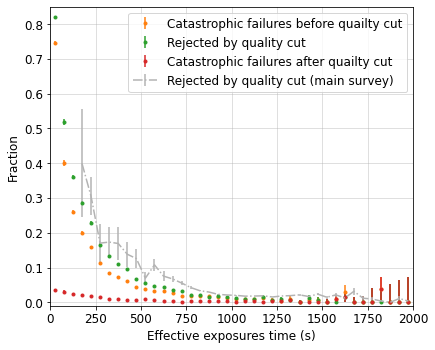

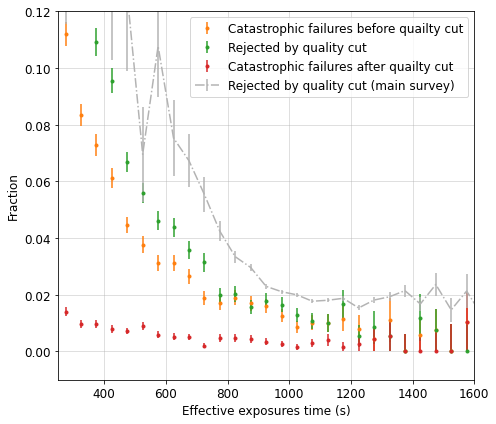

In [17]:
mask = cat['main_lrg'].copy()
bin_edges = np.linspace(0, 2000, 41)
bin_center, bin_reject_rate, bin_reject_rate_err = binned_frac(cat['EFFTIME_LRG'][mask], (~mask_quality)[mask], bin_edges, minsize=10)
bin_center, bin_fail_rate, bin_fail_rate_err = binned_frac(cat['EFFTIME_LRG'][mask], mask_fail[mask], bin_edges, minsize=10)
bin_center, bin_still_fail_rate, bin_still_fail_rate_err = binned_frac(cat['EFFTIME_LRG'][mask], (mask_quality & mask_fail)[mask], bin_edges, minsize=10)

bin_center_main, bin_reject_rate_main, bin_reject_rate_err_main = binned_frac(main['EFFTIME_LRG'], (~mask_quality_main), bin_edges, minsize=10)

plt.figure(figsize=(6.5, 5.5))
plt.errorbar(bin_center, bin_fail_rate, color='C1',
             yerr=(np.clip(bin_fail_rate_err, None, bin_fail_rate), bin_fail_rate_err),
             fmt='.', label='Catastrophic failures before quailty cut')
plt.errorbar(bin_center, bin_reject_rate, color='C2',
             yerr=(np.clip(bin_reject_rate_err, None, bin_reject_rate), bin_reject_rate_err),
             fmt='.', label='Rejected by quality cut')
plt.errorbar(bin_center, bin_still_fail_rate, color='C3',
             yerr=(np.clip(bin_still_fail_rate_err, None, bin_still_fail_rate), bin_still_fail_rate_err),
             fmt='.', label='Catastrophic failures after quailty cut')
plt.errorbar(bin_center_main, bin_reject_rate_main,
             yerr=(np.clip(bin_reject_rate_err_main, None, bin_reject_rate_main), bin_reject_rate_err_main),
             fmt='-.', label='Rejected by quality cut (main survey)', color='0.7')
# plt.xlabel('EFFTIME_LRG')
plt.xlabel('Effective exposures time (s)')
plt.ylabel('Fraction')
plt.grid(alpha=0.5)
plt.legend(loc='upper right')
# plt.title('Main LRGs')
plt.axis([0, 2000, -0.01, 0.85])
plt.show()

plt.figure(figsize=(7., 6.))
plt.errorbar(bin_center, bin_fail_rate, color='C1',
             yerr=(np.clip(bin_fail_rate_err, None, bin_fail_rate), bin_fail_rate_err),
             fmt='.', label='Catastrophic failures before quailty cut')
plt.errorbar(bin_center, bin_reject_rate, color='C2',
             yerr=(np.clip(bin_reject_rate_err, None, bin_reject_rate), bin_reject_rate_err),
             fmt='.', label='Rejected by quality cut')
plt.errorbar(bin_center, bin_still_fail_rate, color='C3',
             yerr=(np.clip(bin_still_fail_rate_err, None, bin_still_fail_rate), bin_still_fail_rate_err),
             fmt='.', label='Catastrophic failures after quailty cut')
plt.errorbar(bin_center_main, bin_reject_rate_main,
             yerr=(np.clip(bin_reject_rate_err_main, None, bin_reject_rate_main), bin_reject_rate_err_main),
             fmt='-.', label='Rejected by quality cut (main survey)', color='0.7')
# plt.xlabel('EFFTIME_LRG')
plt.xlabel('Effective exposures time (s)')
plt.ylabel('Fraction')
plt.grid(alpha=0.5)
plt.legend(loc='upper right')
# plt.title('Main LRGs')
plt.axis([250, 1600, -0.01, 0.12])
plt.tight_layout()
# plt.savefig('/Users/rongpu/git/desi-targets/lrg_paper/figures/main_failure_rate_vs_efftime.pdf')
plt.show()

------------
# Failures rates vs zfiber at nominal conditions

In [18]:
mask_nominal = (cat['EFFTIME_LRG']>800.) & (cat['EFFTIME_LRG']<1200.)
mask_nominal_main = (main['EFFTIME_LRG']>800.) & (main['EFFTIME_LRG']<1200.)
print('Nominal depth', np.sum(mask_nominal), np.sum(~mask_nominal), np.sum(mask_nominal)/len(mask_nominal))
print('Nominal depth (main)', np.sum(mask_nominal_main), np.sum(~mask_nominal_main), np.sum(mask_nominal_main)/len(mask_nominal_main))

Nominal depth 53082 275109 0.16174118120240957
Nominal depth (main) 228313 62057 0.7862830182181355


__SV1 LRGs__

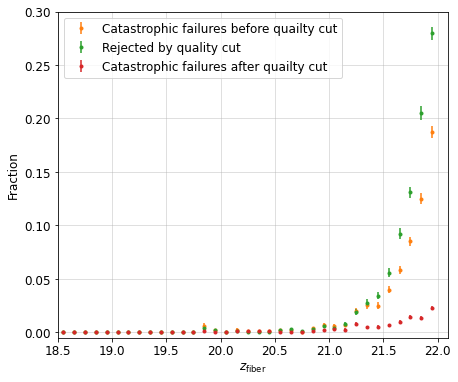

In [19]:
bin_edges = np.linspace(18.0, 22.0, 41)
bin_centers = (bin_edges[1:]+bin_edges[:-1])/2

area = len(main)/600

mask = mask_nominal.copy()
bin_center, bin_reject_rate, bin_reject_rate_err = binned_frac(cat['zfibermag'][mask], (~mask_quality)[mask], bin_edges, minsize=10, error_floor=False)
bin_center, bin_fail_rate, bin_fail_rate_err = binned_frac(cat['zfibermag'][mask], mask_fail[mask], bin_edges, minsize=10, error_floor=False)
bin_center, bin_still_fail_rate, bin_still_fail_rate_err = binned_frac(cat['zfibermag'][mask], (mask_quality & mask_fail)[mask], bin_edges, minsize=10, error_floor=False)

fig, ax1 = plt.subplots(figsize=(7., 6.))
ax1.errorbar(bin_center, bin_fail_rate, color='C1',
             yerr=(np.clip(bin_fail_rate_err, None, bin_fail_rate), bin_fail_rate_err),
             fmt='.', label='Catastrophic failures before quailty cut')
ax1.errorbar(bin_center, bin_reject_rate, color='C2',
             yerr=(np.clip(bin_reject_rate_err, None, bin_reject_rate), bin_reject_rate_err),
             fmt='.', label='Rejected by quality cut')
ax1.errorbar(bin_center, bin_still_fail_rate, color='C3',
             yerr=(np.clip(bin_still_fail_rate_err, None, bin_still_fail_rate), bin_still_fail_rate_err),
             fmt='.', label='Catastrophic failures after quailty cut')
ax1.set_xlabel('$z_\mathrm{fiber}$')
ax1.set_ylabel('Fraction')
ax1.grid(alpha=0.5)
ax1.legend(loc='upper left')
# ax1.title('SV1 LRGs')
ax1.axis([18.5, 22.1, -0.005, 0.3])
plt.show()

__Main LRGs__

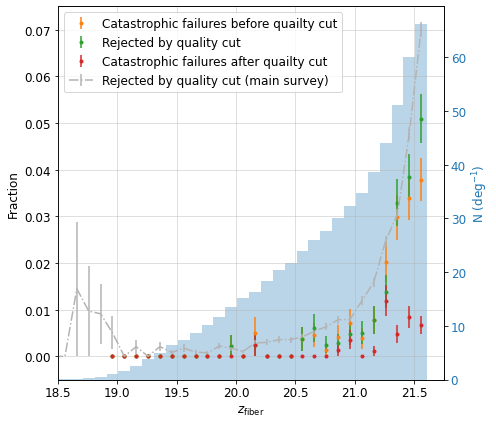

In [20]:
bin_edges = np.linspace(18.01, 22.01, 41)
bin_centers = (bin_edges[1:]+bin_edges[:-1])/2

area = len(main)/600

mask = cat['main_lrg'].copy()
mask &= mask_nominal
bin_center, bin_reject_rate, bin_reject_rate_err = binned_frac(cat['zfibermag'][mask], (~mask_quality)[mask], bin_edges, minsize=10, error_floor=False)
bin_center, bin_fail_rate, bin_fail_rate_err = binned_frac(cat['zfibermag'][mask], mask_fail[mask], bin_edges, minsize=10, error_floor=False)
bin_center, bin_still_fail_rate, bin_still_fail_rate_err = binned_frac(cat['zfibermag'][mask], (mask_quality & mask_fail)[mask], bin_edges, minsize=10, error_floor=False)

mask = mask_nominal_main.copy()
bin_center_main, bin_reject_rate_main, bin_reject_rate_err_main = binned_frac(main['zfibermag'][mask], (~mask_quality_main)[mask], bin_edges, minsize=10, error_floor=False)


fig, ax1 = plt.subplots(figsize=(7., 6.))
ax1.errorbar(bin_center, bin_fail_rate, color='C1',
             yerr=(np.clip(bin_fail_rate_err, None, bin_fail_rate), bin_fail_rate_err),
             fmt='.', label='Catastrophic failures before quailty cut')
ax1.errorbar(bin_center, bin_reject_rate, color='C2',
             yerr=(np.clip(bin_reject_rate_err, None, bin_reject_rate), bin_reject_rate_err),
             fmt='.', label='Rejected by quality cut')
ax1.errorbar(bin_center, bin_still_fail_rate, color='C3',
             yerr=(np.clip(bin_still_fail_rate_err, None, bin_still_fail_rate), bin_still_fail_rate_err),
             fmt='.', label='Catastrophic failures after quailty cut')
ax1.errorbar(bin_center_main, bin_reject_rate_main,
             yerr=(np.clip(bin_reject_rate_err_main, None, bin_reject_rate_main), bin_reject_rate_err_main),
             fmt='-.', label='Rejected by quality cut (main survey)', color='0.7')
ax1.set_xlabel('$z_\mathrm{fiber}$')
ax1.set_ylabel('Fraction')
ax1.grid(alpha=0.5)
ax1.legend(loc='upper left')
# ax1.title('Main LRGs')
ax1.axis([18.5, 21.75, -0.005, 0.075])
ax2 = ax1.twinx()
ax2_color = 'C0'
ax2.hist(main['zfibermag'], bins=bin_edges, color='C0', alpha=0.3, label=None, weights=np.full(len(main), 1/area))
ax2.set_ylabel('N (deg$^{-1}$)', color=ax2_color)
ax2.tick_params(axis='y', labelcolor=ax2_color)

ax1.set_zorder(1)
ax1.patch.set_visible(False)

plt.tight_layout()
# plt.savefig('/Users/rongpu/git/desi-targets/lrg_paper/figures/main_failure_rate_vs_zfiber.pdf')
plt.show()